# GCAP3226 Week 4 — In-class exercise (5%)

**Individual.** Three tasks + submit (Commit & Push → Moodle GitHub URL).

| Task | Do this |
|------|---------|
| **1** | Percentage change by A&E triage; largest fall / rise; triage 4+5 combined |
| **2** | Grouped bar chart: H1 2025 vs H1 2026 attendances by triage (10 bars) + numbers / percentage change |
| **3** | Short write-up: one supporting point + one gap for the A&E claim |


## Setup

Run the next cell. Data: `w4_ae_triage_h1.csv` (**H1** 2025 vs **H1** 2026 attendances by triage).

**H1** = first half of the year (usually **1 January – 30 June**).

**AI:** `Cmd+I` / `Ctrl+I` on a code cell → implement the comment prompt → **Keep**. Interpretations in your own words.


In [4]:
# Setup — run first
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_FILE = "week4_ae_triage_h1.csv"
path = Path(DATA_FILE) if Path(DATA_FILE).is_file() else Path.cwd() / DATA_FILE
df = pd.read_csv(path)
print("Using:", path.resolve())
df



Using: /workspaces/GCAP3226_week4/week4_ae_triage_h1.csv


,triage,triage_name,attend_h1_2025,attend_h1_2026
0,1,Critical,13848,14541
1,2,Emergency,28554,29981
2,3,Urgent,400428,411994
3,4,Semi-urgent,489032,441974
4,5,Non-urgent,18448,14758


## Task 1 — Percentage change

**Purpose:** Measure how A&E attendances changed from H1 2025 to H1 2026 for each triage group, so you can see which groups rose or fell before judging the A&E claim in Task 3.

1. Add a column `pct_change` = `(attend_h1_2026 - attend_h1_2025) / attend_h1_2025 * 100`.
2. Show the table.
3. Print the triage with the **largest fall** and the **largest rise**.
4. Compute the percentage change for triage **4+5 combined** (sum attendances first, then apply the same formula).

Then, in the next cell, write **1–2 sentences** answering:
- Did triage **1–2** (Critical / Emergency) mainly **rise or fall**?
- Did triage **4–5** (Semi-urgent / Non-urgent) mainly **rise or fall**?
- In one short phrase: what does that pattern look like for the A&E claim (lower-urgency down; critical/emergency protected)?


In [5]:
# Task 1
#
# Input: df (triage, triage_name, attend_h1_2025, attend_h1_2026)
# Process: Write Python code to add pct_change, display the table,
#          print largest fall and largest rise; also 4+5 combined percentage change
# Output: table + printed fall/rise + 4+5 combined
#
# YOUR CODE BELOW


df["pct_change"] = (
    (df["attend_h1_2026"] - df["attend_h1_2025"])
    / df["attend_h1_2025"] * 100
)

display(df)

largest_fall = df.loc[df["pct_change"].idxmin()]
largest_rise = df.loc[df["pct_change"].idxmax()]

print(
    f"Largest fall: Triage {largest_fall['triage']} "
    f"({largest_fall['triage_name']}): {largest_fall['pct_change']:.2f}%"
)
print(
    f"Largest rise: Triage {largest_rise['triage']} "
    f"({largest_rise['triage_name']}): {largest_rise['pct_change']:.2f}%"
)

triage_4_5 = df[df["triage"].isin([4, 5])]
combined_2025 = triage_4_5["attend_h1_2025"].sum()
combined_2026 = triage_4_5["attend_h1_2026"].sum()
combined_pct_change = (combined_2026 - combined_2025) / combined_2025 * 100

print(f"Triage 4+5 combined percentage change: {combined_pct_change:.2f}%")

,triage,triage_name,attend_h1_2025,attend_h1_2026,pct_change
0,1,Critical,13848,14541,5.004333
1,2,Emergency,28554,29981,4.997549
2,3,Urgent,400428,411994,2.888409
3,4,Semi-urgent,489032,441974,-9.622683
4,5,Non-urgent,18448,14758,-20.002168


Largest fall: Triage 5 (Non-urgent): -20.00%
Largest rise: Triage 1 (Critical): 5.00%
Triage 4+5 combined percentage change: -10.00%


In [ ]:
# Task 1 note
task1_note = """
- Triage 1–2 has mainly risen.
- Triage 4–5 has fallen significantly.
- A&E Claim: Lower-urgency attendances have decreased, while critical/emergency attendances have been protected. According to the data, triage 1–2 attendances have increased, while triage 4–5 attendances have decreased. This supports the claim that lower-urgency attendances have decreased, while critical/emergency attendances have been protected.
"""
print(task1_note)




- Triage 1–2 has mainly risen.
- Triage 4–5 has fallen significantly.
- A&E Claim: Lower-urgency attendances have decreased, while critical/emergency attendances have been protected. According to the data, triage 1–2 attendances have increased, while triage 4–5 attendances have decreased. This supports the claim that lower-urgency attendances have decreased, while critical/emergency attendances have been protected.



## Task 2 — Visualization

**Purpose:** Turn the Task 1 table into a **grouped bar chart** that compares H1 2025 and H1 2026 attendances for each triage (5 groups, 2 bars each → 10 bars), and makes the **numbers** and **percentage change** easy to see.

In the next code cell, write your own IPO comment prompt, then use Inline Chat to implement it. Interpretations stay in your own words.


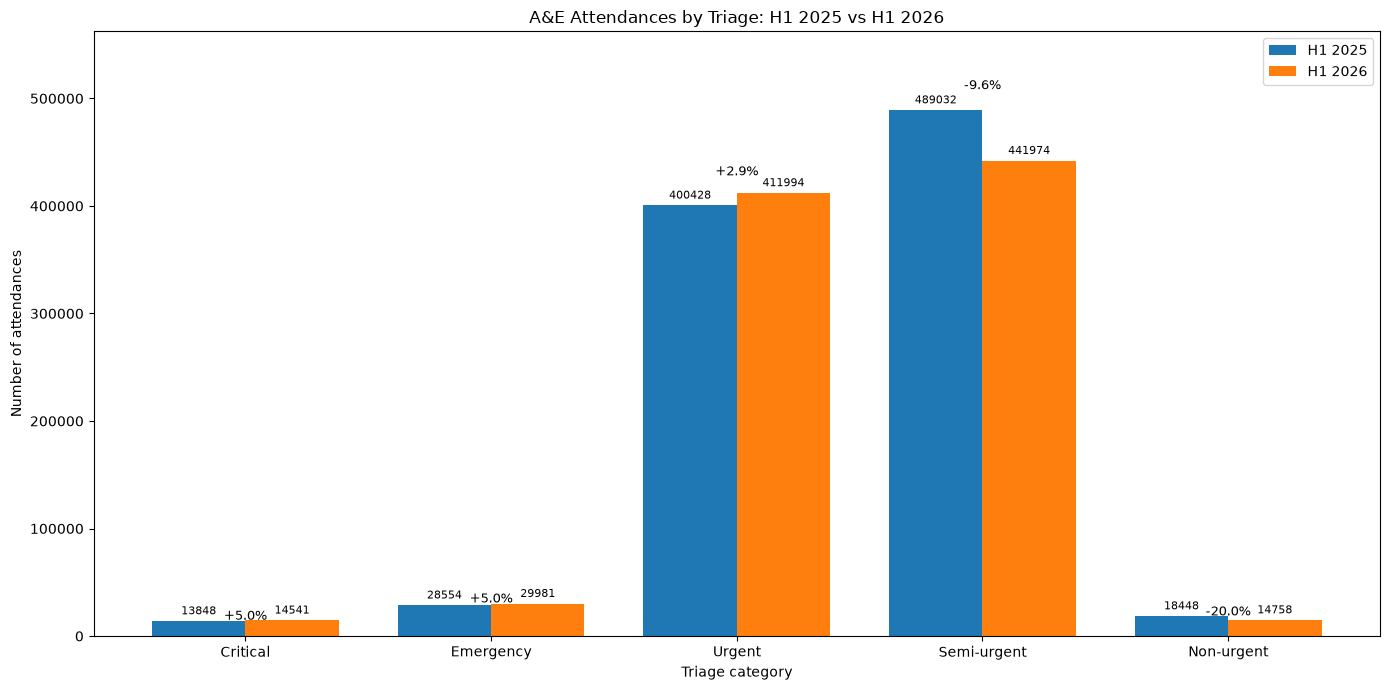

In [11]:
# Task 2 — write your own IPO prompt in the comments, then use Inline Chat
#
# Input: df (triage, triage_name, attend_h1_2025, attend_h1_2026)
#
# Process:
#   Write Python code to make a grouped bar chart that compares H1 2025 and H1 2026 attendances for each triage category. The x-axis should represent the triage categories, and the y-axis should represent the number of attendances. Include a legend to differentiate between the two years.
#
# Output: A grouped bar chart comparing H1 2025 and H1 2026 attendances for each triage category. 
#
# YOUR CODE BELOW

fig, ax = plt.subplots(figsize=(14, 7))

x = range(len(df))
bar_width = 0.38

bars_2025 = ax.bar(
    [i - bar_width / 2 for i in x],
    df["attend_h1_2025"],
    bar_width,
    label="H1 2025"
)
bars_2026 = ax.bar(
    [i + bar_width / 2 for i in x],
    df["attend_h1_2026"],
    bar_width,
    label="H1 2026"
)

ax.set_xticks(list(x))
ax.set_xticklabels(df["triage_name"])
ax.set_xlabel("Triage category")
ax.set_ylabel("Number of attendances")
ax.set_title("A&E Attendances by Triage: H1 2025 vs H1 2026")
ax.legend()

for bars in (bars_2025, bars_2026):
    ax.bar_label(bars, fmt="%.0f", padding=3, fontsize=8)

for i, row in df.iterrows():
    ax.text(
        i,
        max(row["attend_h1_2025"], row["attend_h1_2026"]) * 1.04,
        f"{row['pct_change']:+.1f}%",
        ha="center",
        fontsize=9
    )

ax.set_ylim(0, df[["attend_h1_2025", "attend_h1_2026"]].to_numpy().max() * 1.15)
fig.tight_layout()
plt.show()


## Task 3 — Write-up

**Claim:** After fee reform, A&E improved — lower-urgency attendances fell; critical/emergency care stayed protected; urgent care became more efficient.

You may also cite: triage III within 30 min **81.4 → 88.5** (percentage); mean wait **23 → 20** min.

**3a** — Write **one supporting point** (cite a number) and **one gap** in the evidence.

**3b** — 2–4 sentences: how well is the claim supported by the published evidence (your table / chart, and any figures cited above)?


In [16]:
# Task 3
task3a = "Supporting: Lower emergency attendances have decreased. In traige 1, 2 and 3, the attendance numbers have increased by 5%, 5% and 2.9 % respectively, while triage 4 and 5 have decreased by 9.6% and 20% respectively.Gap: However, the base numbers for triage 1, 2 and 3 are much lower than those for triage 4 and 5. Measuring the percentage change alone can be misleading."

task3b = "3b: The evidence partly supports the claim: triage 4–5 attendances fell, triage 1–2 attendances rose, triage III performance within 30 minutes improved from 81.4% to 88.5%, and mean wait fell from 23 to 20 minutes. However, these figures do not prove fee reform caused the changes, and they do not fully show patient outcomes or whether emergency care was adequately protected. Overall, the results are encouraging but insufficient to confirm that A&E improved because of the reform."

print(task3a)
print("---")
print(task3b)



Supporting: Lower emergency attendances have decreased. In traige 1, 2 and 3, the attendance numbers have increased by 5%, 5% and 2.9 % respectively, while triage 4 and 5 have decreased by 9.6% and 20% respectively.Gap: However, the base numbers for triage 1, 2 and 3 are much lower than those for triage 4 and 5. Measuring the percentage change alone can be misleading.
---
3b: The evidence partly supports the claim: triage 4–5 attendances fell, triage 1–2 attendances rose, triage III performance within 30 minutes improved from 81.4% to 88.5%, and mean wait fell from 23 to 20 minutes. However, these figures do not prove fee reform caused the changes, and they do not fully show patient outcomes or whether emergency care was adequately protected. Overall, the results are encouraging but insufficient to confirm that A&E improved because of the reform.


## Submit

1. Save → Source Control → **Commit & Push**  
2. Moodle: paste your **GitHub URL**
